# Semantic Book Intelligence Research Lab
## Notebook 04 - Classical Semantic Representations and Evaluation

**Primary research question**

> Do description-derived classical semantic representations capture book subject matter better than structured metadata alone, and does combining metadata with text improve generalization to unseen literary works?

**Primary task:** Multi-label classification of well-supported Goodreads genre families using weak, shelf-derived labels.

**Primary metric:** Macro F1. Genre support is imbalanced, so each included genre should contribute equally to model selection rather than allowing the largest genres to dominate.

**Supporting metrics:** Micro F1, macro average precision, per-genre precision/recall/F1, and label coverage.

This notebook establishes the classical semantic baseline for later comparison with transformer embeddings. It does not build SBERT embeddings, topic-model comparisons, clustering systems, collaborative models, graph embeddings, semantic-search applications, or production services.

## 1. Imports, configuration, and reproducibility

In [4]:
from __future__ import annotations

from html import unescape
from pathlib import Path
import json
import re
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    hamming_loss,
    make_scorer,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.svm import LinearSVC

try:
    import plotly
    import plotly.express as px
except ImportError:
    plotly = None
    px = None

RANDOM_STATE = 42
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15
CV_SPLITS = 5
N_JOBS = -1
MIN_DESCRIPTION_WORDS = 20

# Fixed from the prior data-understanding phase. Labels are not selected
# after inspecting the final test partition.
TARGET_GENRES = [
    "fiction",
    "history, historical fiction, biography",
    "romance",
    "non-fiction",
    "fantasy, paranormal",
    "mystery, thriller, crime",
    "young-adult",
    "children",
    "comics, graphic",
    "poetry",
]

# Resolve artifact paths from either the repository root or the notebooks directory.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures" / "notebook04"

# Create only downstream output folders; upstream interim inputs must already exist.
for directory in [PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FILES = {
    "books": INTERIM_DIR / "books_sample.parquet",
    "genres": INTERIM_DIR / "book_genres_sample.parquet",
    "feature_store": PROCESSED_DIR / "book_features_v1.parquet",
}

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid", context="notebook")

version_summary = pd.DataFrame(
    {
        "library": ["Python", "NumPy", "pandas", "scikit-learn", "Matplotlib", "seaborn", "Plotly"],
        "version": [
            sys.version.split()[0],
            np.__version__,
            pd.__version__,
            sklearn.__version__,
            matplotlib.__version__,
            sns.__version__,
            plotly.__version__ if plotly is not None else "not installed (interactive plot skipped)",
        ],
    }
)
display(version_summary)

,library,version
0,Python,3.12.13
1,NumPy,2.5.1
2,pandas,3.0.3
3,scikit-learn,1.9.0
4,Matplotlib,3.11.1
5,seaborn,0.13.2
6,Plotly,not installed (interactive plot skipped)


## 2. Validate and load research artifacts

In [5]:
# Validate upstream artifacts before loading so missing inputs fail early with clear paths.
file_status = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": str(path),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / (1024**2), 3) if path.exists() else np.nan,
        }
        for name, path in FILES.items()
    ]
)
display(file_status)

missing_files = file_status.loc[~file_status["exists"], "path"].tolist()
if missing_files:
    raise FileNotFoundError("Required Notebook 04 inputs are missing:\n" + "\n".join(missing_files))

# Load the research tables and standardize book_id before joins or integrity checks.
books = pd.read_parquet(FILES["books"])
book_genres = pd.read_parquet(FILES["genres"])
feature_store = pd.read_parquet(FILES["feature_store"])

for frame in [books, book_genres, feature_store]:
    if "book_id" in frame.columns:
        frame["book_id"] = frame["book_id"].astype("string")

# Treat required columns and key uniqueness as contracts for reproducible downstream merges.
required_book_columns = {"book_id", "work_id", "title", "description"}
required_genre_columns = {"book_id", "genre"}

if not required_book_columns.issubset(books.columns):
    raise KeyError(f"Books artifact is missing: {sorted(required_book_columns - set(books.columns))}")
if not required_genre_columns.issubset(book_genres.columns):
    raise KeyError(f"Genre artifact is missing: {sorted(required_genre_columns - set(book_genres.columns))}")
if not books["book_id"].is_unique:
    raise ValueError("books_sample.parquet must contain one row per book_id.")
if not feature_store["book_id"].is_unique:
    raise ValueError("book_features_v1.parquet must contain one row per book_id.")

dataset_summary = pd.DataFrame(
    {
        "artifact": ["books", "book_genres", "feature_store"],
        "rows": [len(books), len(book_genres), len(feature_store)],
        "columns": [books.shape[1], book_genres.shape[1], feature_store.shape[1]],
    }
)
display(dataset_summary)

,artifact,path,exists,size_mb
0,books,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/books_sample.parquet,True,3.292
1,genres,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_genres_sampl...,True,0.071
2,feature_store,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/book_features_v...,True,3.537


,artifact,rows,columns
0,books,5000,35
1,book_genres,10663,3
2,feature_store,5000,61


## 3. Normalize descriptions and construct lexical features

Text normalization is deliberately conservative: decode HTML entities, remove markup and URLs, and normalize whitespace. The vectorizers handle case normalization. No stemming or lemmatization is used, which avoids language-specific processing assumptions in this multilingual sample.

Readability values are approximate research features rather than authoritative linguistic measurements. The syllable estimator is intentionally dependency-free and primarily meaningful for English text.

In [6]:
# Compile reusable patterns once because they are applied to every description.
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
WHITESPACE_PATTERN = re.compile(r"\s+")
TOKEN_PATTERN = re.compile(r"\b[\w']+\b", flags=re.UNICODE)
SENTENCE_PATTERN = re.compile(r"[.!?]+")
VOWEL_GROUP_PATTERN = re.compile(r"[aeiouy]+", flags=re.IGNORECASE)


# Remove markup and normalize spacing while preserving words used by later vectorizers.
def normalize_description(value: object) -> str:
    if pd.isna(value):
        return ""
    text = unescape(str(value))
    text = HTML_TAG_PATTERN.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    return WHITESPACE_PATTERN.sub(" ", text).strip()


def approximate_syllables(word: str) -> int:
    normalized = re.sub(r"[^a-z]", "", word.casefold())
    if not normalized:
        return 0
    groups = len(VOWEL_GROUP_PATTERN.findall(normalized))
    if normalized.endswith("e") and groups > 1 and not normalized.endswith(("le", "ye")):
        groups -= 1
    return max(groups, 1)


# Convert each description into interpretable length, diversity, style, and readability features.
def lexical_statistics(text: str) -> dict[str, float]:
    tokens = TOKEN_PATTERN.findall(text)
    words = [token for token in tokens if any(character.isalpha() for character in token)]
    word_count = len(words)
    unique_word_count = len({word.casefold() for word in words})
    sentence_count = max(len(SENTENCE_PATTERN.findall(text)), 1 if word_count else 0)
    character_count = sum(character.isalpha() for character in text)
    uppercase_count = sum(character.isupper() for character in text)
    syllable_count = sum(approximate_syllables(word) for word in words)

    average_words_per_sentence = word_count / sentence_count if sentence_count else 0.0
    average_word_length = sum(len(word) for word in words) / word_count if word_count else 0.0
    lexical_diversity = unique_word_count / word_count if word_count else 0.0
    uppercase_ratio = uppercase_count / character_count if character_count else 0.0

    if word_count and sentence_count:
        flesch_reading_ease = (
            206.835
            - 1.015 * average_words_per_sentence
            - 84.6 * (syllable_count / word_count)
        )
    else:
        flesch_reading_ease = np.nan

    return {
        "text_word_count": word_count,
        "text_unique_word_count": unique_word_count,
        "text_sentence_count": sentence_count,
        "text_average_words_per_sentence": average_words_per_sentence,
        "text_average_word_length": average_word_length,
        "text_lexical_diversity": lexical_diversity,
        "text_flesch_reading_ease": flesch_reading_ease,
        "text_uppercase_ratio": uppercase_ratio,
    }


# Keep raw and cleaned text together, then align derived features to the original row index.
books_text = books[["book_id", "work_id", "title", "description"]].copy()
books_text["clean_description"] = books_text["description"].map(normalize_description)

lexical_features = pd.DataFrame(
    books_text["clean_description"].map(lexical_statistics).tolist(),
    index=books_text.index,
)
books_text = pd.concat([books_text, lexical_features], axis=1)

lexical_feature_columns = lexical_features.columns.tolist()
display(books_text[["book_id", "title", "text_word_count", "text_lexical_diversity"]].head())

,book_id,title,text_word_count,text_lexical_diversity
0,3329556,American Creation: Triumphs and Tragedies in the Founding of the Republic,143,0.692308
1,7745509,"Dangerously Funny: The Uncensored Story of ""The Smothers Brothers Comedy Hour""",203,0.679803
2,22877544,A ritmo de sangre,20,0.850000
3,22779170,Elizabeth Is Missing,232,0.668103
4,17536094,"Kimi ni Todoke - Que Chegue A Você, Volume 04",37,0.837838


## 4. Construct the weak multi-label genre corpus

In [7]:
genre_order = {genre: position for position, genre in enumerate(TARGET_GENRES)}

# Restrict weak labels to predefined genre families and deduplicate book-genre pairs.
selected_genre_rows = book_genres.loc[
    book_genres["genre"].isin(TARGET_GENRES),
    ["book_id", "genre"],
].drop_duplicates()

genre_lists = (
    selected_genre_rows.groupby("book_id")["genre"]
    .agg(lambda values: tuple(sorted(set(values), key=genre_order.get)))
    .rename("genres")
)

metadata_features = [
    "publication_year",
    "edition_age",
    "num_pages_clean",
    "description_length_chars",
    "author_count",
    "series_count",
    "ratings_count",
    "text_reviews_count",
    "popular_shelf_count",
    "similar_book_count",
    "is_ebook",
    "has_description",
    "has_page_count",
    "page_count_zero",
    "page_count_nonpositive",
    "publication_year_plausible",
]

missing_metadata_features = [column for column in metadata_features if column not in feature_store.columns]
if missing_metadata_features:
    raise KeyError(f"Feature store is missing metadata baseline columns: {missing_metadata_features}")

# Inner-join labels to define the cohort, then attach metadata with one-to-one checks.
analysis = (
    books_text.merge(genre_lists, on="book_id", how="inner", validate="one_to_one")
    .merge(
        feature_store[["book_id", *metadata_features]],
        on="book_id",
        how="left",
        validate="one_to_one",
    )
)

# Exclude very short descriptions because they provide too little stable semantic signal.
analysis = analysis.loc[
    analysis["text_word_count"] >= MIN_DESCRIPTION_WORDS
].reset_index(drop=True)

# Group editions by work_id so related editions cannot leak across evaluation partitions.
analysis["work_id"] = analysis["work_id"].astype("string")
analysis["work_group"] = analysis["work_id"].fillna(
    analysis["book_id"].astype("string").radd("__MISSING_WORK_")
)

for column in [*metadata_features, *lexical_feature_columns]:
    analysis[column] = pd.to_numeric(analysis[column], errors="coerce").astype(float)

# Encode each book's genre tuple as a fixed-order multi-label target matrix.
label_binarizer = MultiLabelBinarizer(classes=TARGET_GENRES)
label_matrix = label_binarizer.fit_transform(analysis["genres"])

if len(analysis) < 1_000:
    raise ValueError("The eligible semantic corpus is unexpectedly small; review text and label filters.")

corpus_summary = pd.DataFrame(
    {
        "metric": [
            "source_books",
            "books_with_descriptions",
            "eligible_labeled_books",
            "eligible_work_groups",
            "included_genres",
            "median_description_words",
            "median_labels_per_book",
        ],
        "value": [
            len(books),
            int(books["description"].notna().sum()),
            len(analysis),
            analysis["work_group"].nunique(),
            len(TARGET_GENRES),
            float(analysis["text_word_count"].median()),
            float(label_matrix.sum(axis=1).mean()),
        ],
    }
)
display(corpus_summary)

,metric,value
0,source_books,5000.000000
1,books_with_descriptions,4122.000000
2,eligible_labeled_books,3497.000000
3,eligible_work_groups,3480.000000
4,included_genres,10.000000
5,median_description_words,131.000000
6,median_labels_per_book,2.667715


## 5. Corpus and label visualizations

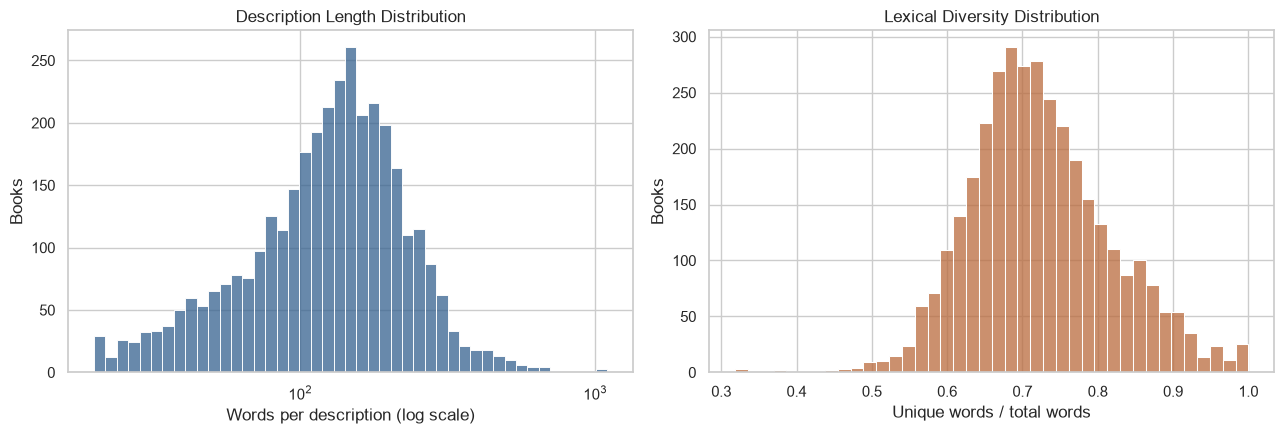

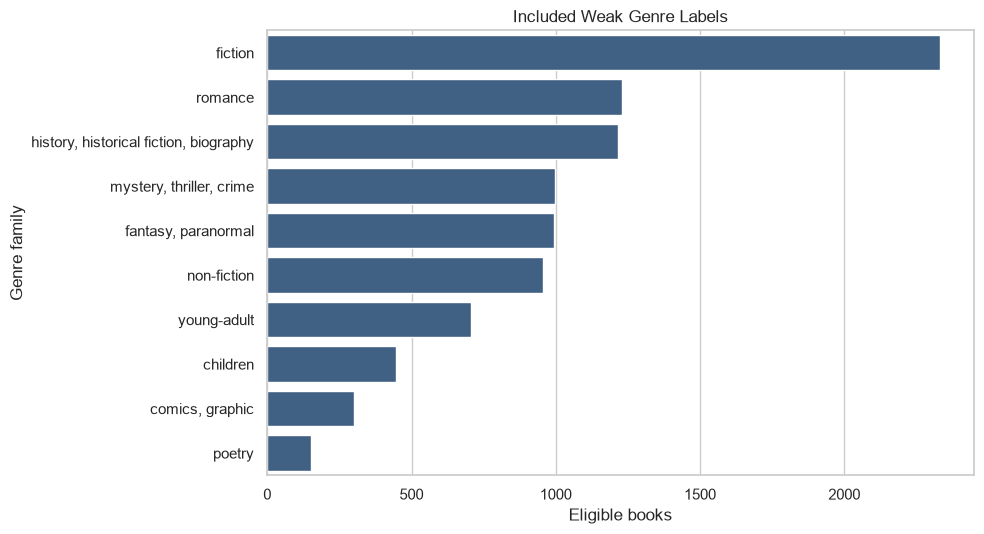

In [8]:
label_prevalence = pd.DataFrame(
    {
        "genre": TARGET_GENRES,
        "books": label_matrix.sum(axis=0).astype(int),
    }
).sort_values("books", ascending=False)
label_prevalence["share"] = label_prevalence["books"] / len(analysis)

description_plot_data = analysis[["text_word_count", "text_lexical_diversity"]].copy()

# Profile continuous text features together; log scaling keeps the long length tail legible.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(
    data=description_plot_data,
    x="text_word_count",
    bins=45,
    log_scale=(True, False),
    ax=axes[0],
    color="#35618f",
)
axes[0].set_title("Description Length Distribution")
axes[0].set_xlabel("Words per description (log scale)")
axes[0].set_ylabel("Books")

sns.histplot(
    data=description_plot_data,
    x="text_lexical_diversity",
    bins=40,
    ax=axes[1],
    color="#ba6b3d",
)
axes[1].set_title("Lexical Diversity Distribution")
axes[1].set_xlabel("Unique words / total words")
axes[1].set_ylabel("Books")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "description_profile.png", dpi=160, bbox_inches="tight")
plt.show()

# Plot class support to make label imbalance visible before model selection.
plt.figure(figsize=(10, 5.5))
sns.barplot(data=label_prevalence, y="genre", x="books", color="#35618f")
plt.title("Included Weak Genre Labels")
plt.xlabel("Eligible books")
plt.ylabel("Genre family")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "genre_prevalence.png", dpi=160, bbox_inches="tight")
plt.show()

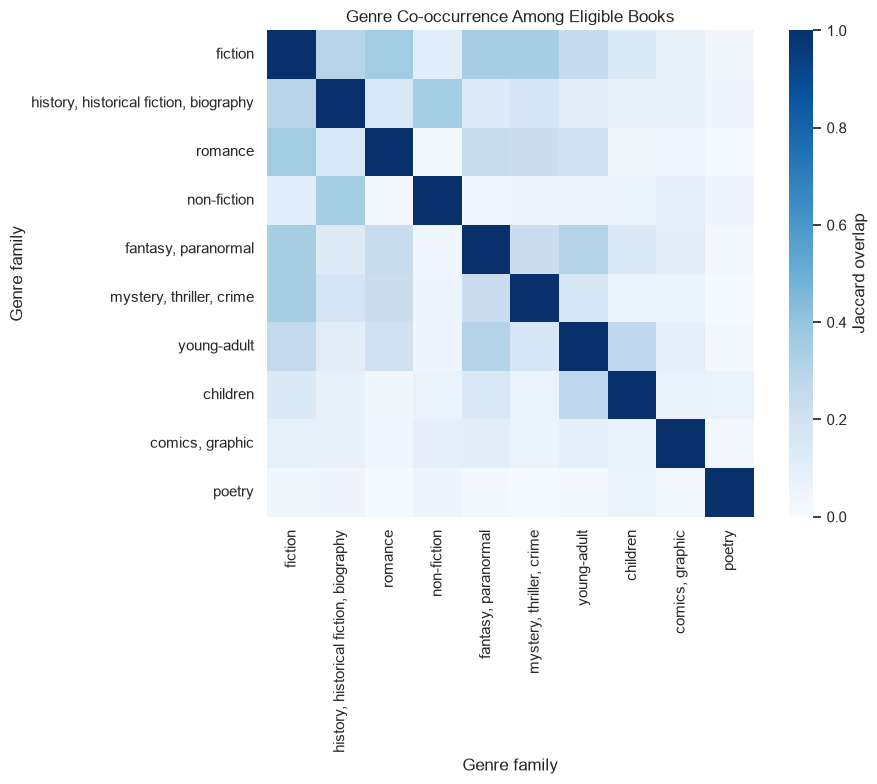

In [9]:
# Use Jaccard overlap to normalize co-occurrence by the union of each genre pair.
cooccurrence_counts = label_matrix.T @ label_matrix
genre_support = np.diag(cooccurrence_counts)
union_counts = genre_support[:, None] + genre_support[None, :] - cooccurrence_counts
genre_jaccard = np.divide(
    cooccurrence_counts,
    union_counts,
    out=np.zeros_like(cooccurrence_counts, dtype=float),
    where=union_counts > 0,
)

genre_jaccard_df = pd.DataFrame(
    genre_jaccard,
    index=TARGET_GENRES,
    columns=TARGET_GENRES,
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    genre_jaccard_df,
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Jaccard overlap"},
)
plt.title("Genre Co-occurrence Among Eligible Books")
plt.xlabel("Genre family")
plt.ylabel("Genre family")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "genre_cooccurrence.png", dpi=160, bbox_inches="tight")
plt.show()

### Result interpretation — corpus, text profile, and label structure

- Of 5,000 sampled books, 4,122 (82.4%) have descriptions and 3,497 (69.9%) meet the text and label eligibility rules. The 3,480 work groups show that only a small number of related editions remain in the modeling cohort.
- Eligible descriptions have a median length of 131 words (interquartile range 84–185; observed range 20–1,099). Lexical diversity has a median of 0.714 (interquartile range 0.661–0.779); unusually high ratios often belong to short descriptions and should be interpreted jointly with length.
- The task is genuinely multi-label: books average 2.668 included labels and the median is 3. The corpus-summary row named `median_labels_per_book` is mislabeled because its code uses `.mean()`; the displayed 2.6677 is the mean.
- Label support is strongly imbalanced: fiction has 2,333 eligible books, while comics/graphic has 299 and poetry has 153. This approximately 15:1 range supports Macro F1 as the primary metric and balanced class weights in the classifiers.
- The strongest Jaccard overlaps are fiction–romance (0.363), history/non-fiction (0.352), fiction–fantasy (0.344), fiction–mystery (0.344), and fantasy–young-adult (0.304). These overlaps confirm that the weak genres are related, non-exclusive signals rather than clean single-class ground truth.

## 6. Create frozen work-group splits

The split uses `work_id` groups so editions of the same literary work cannot appear in multiple partitions. Hyperparameters are selected using group-aware cross-validation on the training partition. Validation data selects the winning experiment. The final test partition is used once for the selected model.

In [10]:
# Split on work_group, not individual books, to keep editions of the same work together.
def create_grouped_split_manifest(frame: pd.DataFrame) -> pd.DataFrame:
    outer_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    development_positions, test_positions = next(
        outer_splitter.split(frame, groups=frame["work_group"])
    )

    development = frame.iloc[development_positions]
    # Convert the desired total validation share to a share of the remaining development rows.
    relative_validation_size = VALIDATION_SIZE / (1.0 - TEST_SIZE)
    inner_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=relative_validation_size,
        random_state=RANDOM_STATE + 1,
    )
    train_relative_positions, validation_relative_positions = next(
        inner_splitter.split(development, groups=development["work_group"])
    )

    train_positions = development_positions[train_relative_positions]
    validation_positions = development_positions[validation_relative_positions]

    split = np.full(len(frame), "", dtype=object)
    split[train_positions] = "train"
    split[validation_positions] = "validation"
    split[test_positions] = "test"

    if (split == "").any():
        raise RuntimeError("Every eligible row must receive exactly one split assignment.")

    return pd.DataFrame(
        {
            "book_id": frame["book_id"],
            "work_id": frame["work_id"],
            "work_group": frame["work_group"],
            "split": split,
            "random_state": RANDOM_STATE,
        }
    )


split_manifest = create_grouped_split_manifest(analysis)
analysis["split"] = split_manifest["split"]

split_order = ["train", "validation", "test"]
split_summary = (
    analysis.groupby("split", observed=True)
    .agg(books=("book_id", "size"), work_groups=("work_group", "nunique"))
    .reindex(split_order)
)
split_summary["book_share"] = split_summary["books"] / len(analysis)

# Explicitly verify that no work group appears in more than one partition.
group_sets = {
    split_name: set(analysis.loc[analysis["split"] == split_name, "work_group"])
    for split_name in split_order
}
for left_index, left_name in enumerate(split_order):
    for right_name in split_order[left_index + 1 :]:
        overlap = group_sets[left_name] & group_sets[right_name]
        if overlap:
            raise RuntimeError(f"Work-group leakage between {left_name} and {right_name}: {len(overlap)}")

# Confirm every target is learnable in CV and evaluable in both held-out partitions.
label_coverage_by_split = pd.DataFrame(label_matrix, columns=TARGET_GENRES)
label_coverage_by_split["split"] = analysis["split"].to_numpy()
label_coverage_by_split = (
    label_coverage_by_split.groupby("split")[TARGET_GENRES]
    .sum()
    .reindex(split_order)
    .T
    .astype(int)
)

if (label_coverage_by_split["train"] < CV_SPLITS).any():
    insufficient = label_coverage_by_split.index[label_coverage_by_split["train"] < CV_SPLITS].tolist()
    raise ValueError(f"Insufficient training support for group cross-validation: {insufficient}")
if (label_coverage_by_split[["validation", "test"]] == 0).any().any():
    raise ValueError("Every included genre must appear in both validation and test partitions.")

split_manifest.to_parquet(PROCESSED_DIR / "research_split_v1.parquet", index=False)
display(split_summary)
display(label_coverage_by_split)

,books,work_groups,book_share
split,,,
train,2446,2436,0.699457
validation,525,522,0.150129
test,526,522,0.150415


split,train,validation,test
fiction,1633,353,347
"history, historical fiction, biography",838,179,198
romance,860,193,177
non-fiction,649,152,155
"fantasy, paranormal",688,155,150
"mystery, thriller, crime",704,147,148
young-adult,499,100,106
children,326,54,66
"comics, graphic",201,49,49
poetry,95,28,30


### Result interpretation — frozen split quality

- The split contains 2,446 training, 525 validation, and 526 test books, closely matching the intended 70%/15%/15% allocation. The corresponding work-group counts are 2,436, 522, and 522.
- The explicit overlap checks passed, so no `work_id` group appears in more than one partition. This prevents alternate editions of the same work from inflating generalization estimates.
- Every target genre appears in every partition and has enough training examples for five-fold grouped cross-validation. Poetry remains the smallest target with 95/28/30 train/validation/test positives, followed by comics/graphic with 201/49/49; results for these labels will therefore have greater uncertainty.
- The split is group-aware but not explicitly multi-label-stratified. Coverage is adequate for this prototype, while future larger-sample work should continue monitoring label balance across partitions.

## 7. Define leakage-safe representation pipelines

In [11]:
# Apply the same median-imputation and scaling treatment to all numeric baselines.
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]
)


# Bound the word-level TF-IDF vocabulary to balance semantic coverage and memory use.
def word_vectorizer(max_features: int = 40_000) -> TfidfVectorizer:
    return TfidfVectorizer(
        analyzer="word",
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        max_features=max_features,
        sublinear_tf=True,
        dtype=np.float32,
    )


# Character n-grams capture subword patterns and make the text baseline less brittle.
def character_vectorizer(max_features: int = 30_000) -> TfidfVectorizer:
    return TfidfVectorizer(
        analyzer="char_wb",
        lowercase=True,
        ngram_range=(3, 5),
        min_df=3,
        max_features=max_features,
        sublinear_tf=True,
        dtype=np.float32,
    )


# Builders create fresh transformers so fitted state is never reused across experiments.
# Each entry isolates one representation family for a controlled comparison.
representation_builders = {
    "Metadata": lambda: ColumnTransformer(
        [("metadata", clone(numeric_pipeline), metadata_features)],
        remainder="drop",
        verbose_feature_names_out=False,
    ),
    "Lexical": lambda: ColumnTransformer(
        [("lexical", clone(numeric_pipeline), lexical_feature_columns)],
        remainder="drop",
        verbose_feature_names_out=False,
    ),
    "Word TF-IDF": lambda: ColumnTransformer(
        [("word_tfidf", word_vectorizer(), "clean_description")],
        remainder="drop",
        verbose_feature_names_out=False,
    ),
    "Word + Character TF-IDF": lambda: ColumnTransformer(
        [
            ("word_tfidf", word_vectorizer(), "clean_description"),
            ("character_tfidf", character_vectorizer(), "clean_description"),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    ),
    "LSA": lambda: ColumnTransformer(
        [
            (
                "lsa",
                Pipeline(
                    [
                        ("tfidf", word_vectorizer(max_features=30_000)),
                        (
                            "svd",
                            TruncatedSVD(
                                n_components=100,
                                n_iter=7,
                                random_state=RANDOM_STATE,
                            ),
                        ),
                        ("scaler", StandardScaler()),
                    ]
                ),
                "clean_description",
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    ),
    "Combined": lambda: ColumnTransformer(
        [
            ("word_tfidf", word_vectorizer(), "clean_description"),
            ("metadata", clone(numeric_pipeline), metadata_features),
            ("lexical", clone(numeric_pipeline), lexical_feature_columns),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=False,
    ),
}

# One-vs-rest trains an independent binary classifier for each possible genre label.
model_builders = {
    "Logistic Regression": lambda: OneVsRestClassifier(
        LogisticRegression(
            solver="liblinear",
            max_iter=5_000,
            random_state=RANDOM_STATE,
        )
    ),
    "Linear SVM": lambda: OneVsRestClassifier(
        LinearSVC(
            dual="auto",
            tol=1e-3,
            max_iter=10_000,
            random_state=RANDOM_STATE,
        )
    ),
}

# Tune regularization under class balancing; GridSearchCV will select by Macro F1.
parameter_grids = {
    "Logistic Regression": {
        "classifier__estimator__C": [0.1, 1.0, 10.0],
        "classifier__estimator__class_weight": ["balanced"],
    },
    "Linear SVM": {
        "classifier__estimator__C": [0.05, 0.1, 1.0],
        "classifier__estimator__class_weight": ["balanced"],
    },
}

representation_summary = pd.DataFrame(
    {
        "representation": list(representation_builders),
        "role": [
            "Structured baseline",
            "Interpretable text statistics",
            "Sparse semantic baseline",
            "Sparse semantic robustness",
            "Dense classical semantics",
            "Metadata plus semantic features",
        ],
    }
)
display(representation_summary)

,representation,role
0,Metadata,Structured baseline
1,Lexical,Interpretable text statistics
2,Word TF-IDF,Sparse semantic baseline
3,Word + Character TF-IDF,Sparse semantic robustness
4,LSA,Dense classical semantics
5,Combined,Metadata plus semantic features


## 8. Training-only vocabulary and sparsity diagnostics

In [12]:
# Fit diagnostics on training text only to report vocabulary size and matrix density safely.
diagnostic_train_text = analysis.loc[
    analysis["split"] == "train",
    "clean_description",
]

diagnostic_vectorizers = {
    "Word TF-IDF": word_vectorizer(),
    "Character TF-IDF": character_vectorizer(),
}
vocabulary_rows = []

for representation_name, vectorizer in diagnostic_vectorizers.items():
    training_matrix = vectorizer.fit_transform(diagnostic_train_text)
    total_cells = training_matrix.shape[0] * training_matrix.shape[1]
    vocabulary_rows.append(
        {
            "representation": representation_name,
            "training_books": training_matrix.shape[0],
            "features": training_matrix.shape[1],
            "nonzero_values": training_matrix.nnz,
            "density": training_matrix.nnz / total_cells if total_cells else np.nan,
        }
    )

vocabulary_diagnostics = pd.DataFrame(vocabulary_rows)
display(vocabulary_diagnostics)

,representation,training_books,features,nonzero_values,density
0,Word TF-IDF,2446,25213,311051,0.005044
1,Character TF-IDF,2446,30000,2488053,0.033906


### Result interpretation — vocabulary size and sparsity

- Word TF-IDF produced 25,213 eligible features, below its 40,000-feature ceiling, and averages about 127 nonzero word features per training book. Its 0.50% density is expected sparse-text behavior, not missing data.
- Character TF-IDF reached its 30,000-feature ceiling, indicating that the cap is binding. It averages about 1,017 nonzero character features per book and is approximately 6.7 times denser than the word matrix.
- Character n-grams provide broader coverage of spelling, morphology, and multilingual word fragments, but increase memory and fitting cost. The combined sparse representation remains suitable for linear classifiers and should never be converted to a dense matrix.

## 9. Metrics and experiment utilities

In [13]:
# Use Macro F1 for selection so rare and common genres receive equal weight.
macro_f1_scorer = make_scorer(f1_score, average="macro", zero_division=0)
micro_f1_scorer = make_scorer(f1_score, average="micro", zero_division=0)
scoring = {
    "macro_f1": macro_f1_scorer,
    "micro_f1": micro_f1_scorer,
}


# Retrieve comparable continuous scores from models that expose margins or probabilities.
def prediction_scores(estimator: Pipeline, features: pd.DataFrame) -> np.ndarray | None:
    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(features))
    if hasattr(estimator, "predict_proba"):
        return np.asarray(estimator.predict_proba(features))
    return None


# Report complementary metrics because exact-match accuracy is strict for multi-label data.
def multilabel_metrics(
    true_labels: np.ndarray,
    predicted_labels: np.ndarray,
    scores: np.ndarray | None = None,
) -> dict[str, float]:
    metrics = {
        "macro_f1": f1_score(true_labels, predicted_labels, average="macro", zero_division=0),
        "micro_f1": f1_score(true_labels, predicted_labels, average="micro", zero_division=0),
        "weighted_f1": f1_score(true_labels, predicted_labels, average="weighted", zero_division=0),
        "subset_accuracy": accuracy_score(true_labels, predicted_labels),
        "hamming_loss": hamming_loss(true_labels, predicted_labels),
    }
    metrics["macro_average_precision"] = (
        average_precision_score(true_labels, scores, average="macro")
        if scores is not None
        else np.nan
    )
    return metrics


# Materialize fixed train, validation, and test arrays from the persisted split assignment.
train_mask = analysis["split"].eq("train").to_numpy()
validation_mask = analysis["split"].eq("validation").to_numpy()
test_mask = analysis["split"].eq("test").to_numpy()

X_train = analysis.loc[train_mask].copy()
X_validation = analysis.loc[validation_mask].copy()
X_test = analysis.loc[test_mask].copy()
y_train = label_matrix[train_mask]
y_validation = label_matrix[validation_mask]
y_test = label_matrix[test_mask]
train_groups = analysis.loc[train_mask, "work_group"]

# Keep work groups intact inside every cross-validation fold.
cv_strategy = GroupKFold(n_splits=CV_SPLITS)

## 10. Naive prevalence baseline

In [14]:
# Establish a no-feature prevalence baseline to verify that learned models add signal.
training_prevalence = y_train.mean(axis=0)
naive_label_vector = (training_prevalence >= 0.5).astype(int)
naive_validation_predictions = np.tile(naive_label_vector, (len(y_validation), 1))
naive_validation_metrics = multilabel_metrics(y_validation, naive_validation_predictions)

naive_summary = pd.DataFrame(
    [
        {
            "representation": "Naive prevalence",
            "model": "Most-common label decision",
            "cv_macro_f1_mean": np.nan,
            "cv_macro_f1_std": np.nan,
            "validation_macro_f1": naive_validation_metrics["macro_f1"],
            "validation_micro_f1": naive_validation_metrics["micro_f1"],
            "validation_macro_average_precision": np.nan,
            "best_parameters": json.dumps({"prevalence_threshold": 0.5}),
        }
    ]
)
display(naive_summary)

,representation,model,cv_macro_f1_mean,cv_macro_f1_std,validation_macro_f1,validation_micro_f1,validation_macro_average_precision,best_parameters
0,Naive prevalence,Most-common label decision,NaN,NaN,0.08041,0.364858,NaN,"{""prevalence_threshold"": 0.5}"


### Result interpretation — naive baseline

- Fiction is the only training label with prevalence at or above 0.50, so this baseline predicts fiction for every validation book and predicts no other genre.
- Its validation Macro F1 is only 0.0804, while Micro F1 is 0.3649 because the frequent fiction label dominates aggregate decisions. This gap demonstrates why Micro F1 alone would be misleading for the imbalanced task.
- The baseline establishes a deliberately weak floor: a useful learned representation must improve performance across the full label set, not merely reproduce the most common genre.

## 11. Group-aware cross-validation and bounded grid search

Each representation is evaluated with the same train/validation partition and model grids. Grid search refits on Macro F1. The final test partition is not accessed in this section.

In [15]:
# Evaluate every representation-model pair under identical grouped folds and search rules.
experiment_rows = []
best_parameters_by_experiment = {}

for representation_name, representation_builder in representation_builders.items():
    for model_name, model_builder in model_builders.items():
        experiment_name = (representation_name, model_name)
        experiment_pipeline = Pipeline(
            [
                ("features", representation_builder()),
                ("classifier", model_builder()),
            ]
        )

        search = GridSearchCV(
            estimator=experiment_pipeline,
            param_grid=parameter_grids[model_name],
            scoring=scoring,
            refit="macro_f1",
            cv=cv_strategy,
            n_jobs=N_JOBS,
            return_train_score=False,
            error_score="raise",
        )
        # Pipeline fitting keeps feature learning inside each training fold and prevents leakage.
        search.fit(X_train, y_train, groups=train_groups)

        # Score the best cross-validated configuration on validation data for final selection.
        validation_predictions = search.best_estimator_.predict(X_validation)
        validation_scores = prediction_scores(search.best_estimator_, X_validation)
        validation_metrics = multilabel_metrics(
            y_validation,
            validation_predictions,
            validation_scores,
        )

        best_index = search.best_index_
        best_parameters_by_experiment[experiment_name] = search.best_params_
        experiment_rows.append(
            {
                "representation": representation_name,
                "model": model_name,
                "cv_macro_f1_mean": search.cv_results_["mean_test_macro_f1"][best_index],
                "cv_macro_f1_std": search.cv_results_["std_test_macro_f1"][best_index],
                "cv_micro_f1_mean": search.cv_results_["mean_test_micro_f1"][best_index],
                "validation_macro_f1": validation_metrics["macro_f1"],
                "validation_micro_f1": validation_metrics["micro_f1"],
                "validation_macro_average_precision": validation_metrics["macro_average_precision"],
                "best_parameters": json.dumps(search.best_params_, sort_keys=True),
            }
        )

        # Emit one concise line per experiment while retaining full results in the table.
        print(
            f"{representation_name} | {model_name}: "
            f"CV Macro F1={search.best_score_:.3f}; "
            f"Validation Macro F1={validation_metrics['macro_f1']:.3f}"
        )

model_comparison = pd.concat(
    [naive_summary, pd.DataFrame(experiment_rows)],
    ignore_index=True,
).sort_values(
    ["validation_macro_f1", "cv_macro_f1_mean"],
    ascending=False,
    na_position="last",
).reset_index(drop=True)

display(model_comparison.round(4))

Metadata | Logistic Regression: CV Macro F1=0.473; Validation Macro F1=0.471
Metadata | Linear SVM: CV Macro F1=0.473; Validation Macro F1=0.471
Lexical | Logistic Regression: CV Macro F1=0.414; Validation Macro F1=0.427
Lexical | Linear SVM: CV Macro F1=0.410; Validation Macro F1=0.424
Word TF-IDF | Logistic Regression: CV Macro F1=0.538; Validation Macro F1=0.525
Word TF-IDF | Linear SVM: CV Macro F1=0.536; Validation Macro F1=0.526
Word + Character TF-IDF | Logistic Regression: CV Macro F1=0.578; Validation Macro F1=0.558
Word + Character TF-IDF | Linear SVM: CV Macro F1=0.580; Validation Macro F1=0.563
LSA | Logistic Regression: CV Macro F1=0.543; Validation Macro F1=0.560
LSA | Linear SVM: CV Macro F1=0.538; Validation Macro F1=0.559
Combined | Logistic Regression: CV Macro F1=0.578; Validation Macro F1=0.561
Combined | Linear SVM: CV Macro F1=0.569; Validation Macro F1=0.559


,representation,model,cv_macro_f1_mean,cv_macro_f1_std,validation_macro_f1,validation_micro_f1,validation_macro_average_precision,best_parameters,cv_micro_f1_mean
0,Word + Character TF-IDF,Linear SVM,0.5803,0.0163,0.5626,0.6726,0.6351,"{""classifier__estimator__C"": 0.05, ""classifier__estimator__class_weight"": ""balanced""}",0.6802
1,Combined,Logistic Regression,0.5776,0.0222,0.5611,0.6873,0.6226,"{""classifier__estimator__C"": 10.0, ""classifier__estimator__class_weight"": ""balanced""}",0.6845
2,LSA,Logistic Regression,0.5429,0.0101,0.5596,0.6306,0.5879,"{""classifier__estimator__C"": 0.1, ""classifier__estimator__class_weight"": ""balanced""}",0.6213
3,LSA,Linear SVM,0.5385,0.0112,0.5591,0.6313,0.5845,"{""classifier__estimator__C"": 1.0, ""classifier__estimator__class_weight"": ""balanced""}",0.6212
4,Combined,Linear SVM,0.5689,0.0261,0.5585,0.6851,0.6244,"{""classifier__estimator__C"": 1.0, ""classifier__estimator__class_weight"": ""balanced""}",0.6827
5,Word + Character TF-IDF,Logistic Regression,0.5778,0.0122,0.5578,0.6715,0.6399,"{""classifier__estimator__C"": 1.0, ""classifier__estimator__class_weight"": ""balanced""}",0.6822
6,Word TF-IDF,Linear SVM,0.5364,0.0192,0.5264,0.6588,0.6005,"{""classifier__estimator__C"": 0.1, ""classifier__estimator__class_weight"": ""balanced""}",0.6564
7,Word TF-IDF,Logistic Regression,0.5378,0.0186,0.5252,0.6602,0.6055,"{""classifier__estimator__C"": 1.0, ""classifier__estimator__class_weight"": ""balanced""}",0.6571
8,Metadata,Linear SVM,0.4734,0.0078,0.4707,0.5254,0.4498,"{""classifier__estimator__C"": 1.0, ""classifier__estimator__class_weight"": ""balanced""}",0.5244
9,Metadata,Logistic Regression,0.4732,0.0094,0.4707,0.5270,0.4495,"{""classifier__estimator__C"": 0.1, ""classifier__estimator__class_weight"": ""balanced""}",0.5253


## 12. Compare cross-validation and validation performance

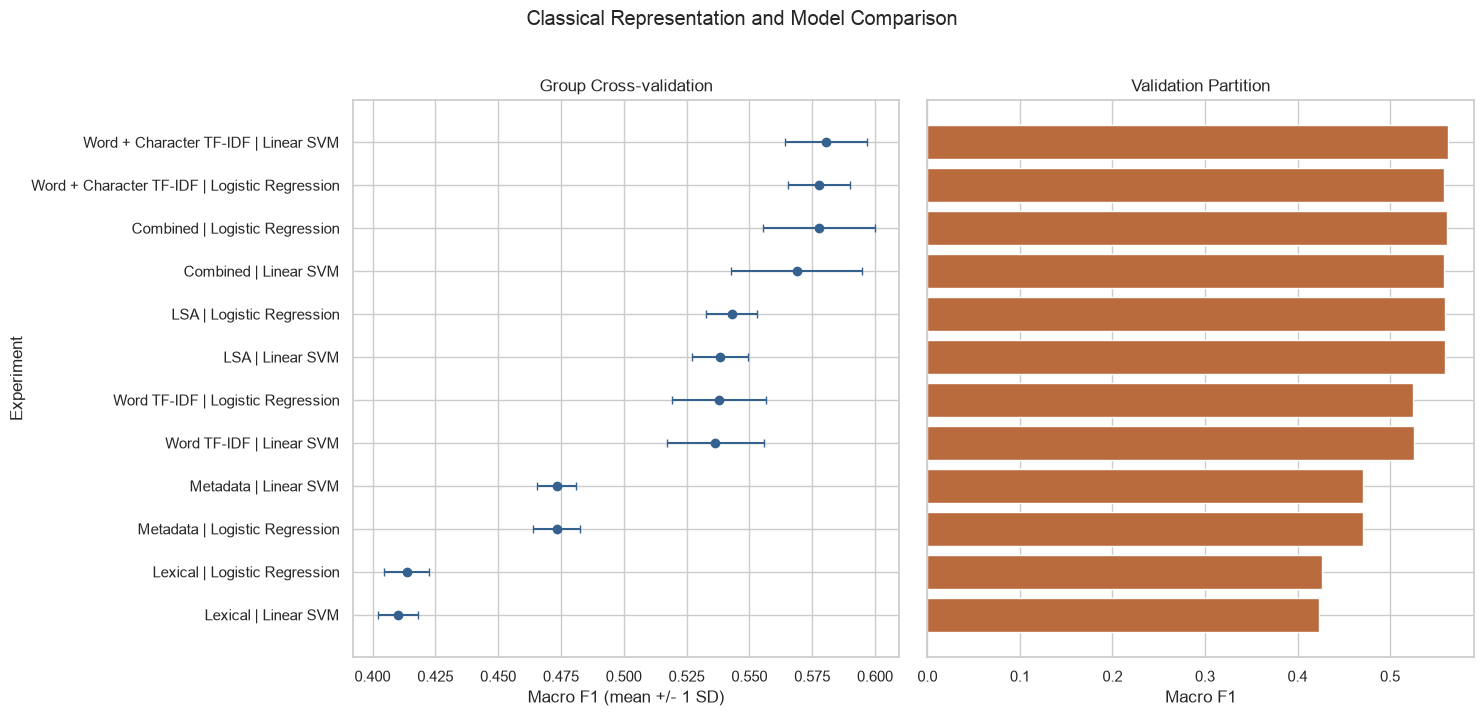

In [16]:
# Compare cross-validation stability with held-out validation performance for each experiment.
comparison_plot_data = model_comparison.loc[
    model_comparison["representation"] != "Naive prevalence"
].copy()
comparison_plot_data["experiment"] = (
    comparison_plot_data["representation"]
    + " | "
    + comparison_plot_data["model"]
)
comparison_plot_data = comparison_plot_data.sort_values("cv_macro_f1_mean")

y_positions = np.arange(len(comparison_plot_data))
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

axes[0].errorbar(
    comparison_plot_data["cv_macro_f1_mean"],
    y_positions,
    xerr=comparison_plot_data["cv_macro_f1_std"],
    fmt="o",
    color="#35618f",
    capsize=3,
)
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(comparison_plot_data["experiment"])
axes[0].set_title("Group Cross-validation")
axes[0].set_xlabel("Macro F1 (mean +/- 1 SD)")
axes[0].set_ylabel("Experiment")

axes[1].barh(
    y_positions,
    comparison_plot_data["validation_macro_f1"],
    color="#ba6b3d",
)
axes[1].set_title("Validation Partition")
axes[1].set_xlabel("Macro F1")
axes[1].tick_params(axis="y", labelleft=False)

plt.suptitle("Classical Representation and Model Comparison", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

### Result interpretation — representation and model comparison

- Word + Character TF-IDF with Linear SVM leads both grouped cross-validation (0.5803 ± 0.0163 Macro F1) and validation Macro F1 (0.5626). Its validation result is lower than the CV mean but remains close to the observed fold variation.
- The leading validation results are tightly grouped: Combined Logistic Regression reaches 0.5611, LSA Logistic Regression 0.5596, LSA Linear SVM 0.5591, and Combined Linear SVM 0.5585. Their overlapping fold variability means the selected winner is not decisively separated from every alternative.
- Representation choice matters more than classifier choice. Adding character n-grams improves the best word-only validation result from 0.5264 to 0.5626, while Logistic Regression and Linear SVM are generally close within the same representation.
- Semantic-only text improves on metadata by 0.0919 validation Macro F1. The Combined representation reaches 0.5611 and therefore does not add measurable Macro F1 beyond the best semantic-only model.
- Supporting metrics favor different candidates: Combined Logistic Regression has the highest validation Micro F1 (0.6873), and Word + Character TF-IDF Logistic Regression has the highest validation macro average precision (0.6399). The predetermined Macro F1 rule correctly prevents switching winners after inspecting secondary metrics.

## 13. Select on validation, refit on development data, and evaluate test once

The winning non-naive experiment is selected by validation Macro F1, with cross-validation Macro F1 as a tie-breaker. It is then refit on the combined train and validation partitions. Only this selected model is evaluated on the final test partition.

In [17]:
# Select once using validation Macro F1, then lock the representation, model, and parameters.
selectable_results = model_comparison.loc[
    model_comparison["representation"] != "Naive prevalence"
].sort_values(
    ["validation_macro_f1", "cv_macro_f1_mean"],
    ascending=False,
)
selected_row = selectable_results.iloc[0]
selected_representation = selected_row["representation"]
selected_model = selected_row["model"]
selected_key = (selected_representation, selected_model)

final_pipeline = Pipeline(
    [
        ("features", representation_builders[selected_representation]()),
        ("classifier", model_builders[selected_model]()),
    ]
)
final_pipeline.set_params(**best_parameters_by_experiment[selected_key])

# Refit on train plus validation only after selection; the test partition remains untouched.
development_mask = analysis["split"].isin(["train", "validation"]).to_numpy()
X_development = analysis.loc[development_mask].copy()
y_development = label_matrix[development_mask]

final_pipeline.fit(X_development, y_development)

# Evaluate the locked pipeline on the final test partition exactly once.
final_test_predictions = final_pipeline.predict(X_test)
final_test_scores = prediction_scores(final_pipeline, X_test)
final_test_metric_values = multilabel_metrics(
    y_test,
    final_test_predictions,
    final_test_scores,
)

final_test_metrics = pd.DataFrame(
    [
        {
            "representation": selected_representation,
            "model": selected_model,
            **final_test_metric_values,
        }
    ]
)

print(f"Selected representation: {selected_representation}")
print(f"Selected model: {selected_model}")
display(final_test_metrics.round(4))

Selected representation: Word + Character TF-IDF
Selected model: Linear SVM


,representation,model,macro_f1,micro_f1,weighted_f1,subset_accuracy,hamming_loss,macro_average_precision
0,Word + Character TF-IDF,Linear SVM,0.5681,0.6774,0.6695,0.1749,0.1755,0.6419


### Result interpretation — final held-out performance

- After refitting on train plus validation data, the selected Word + Character TF-IDF / Linear SVM pipeline achieves 0.5681 test Macro F1. This is close to its 0.5626 validation score and 0.5803 cross-validation mean, providing no sign of a final-test performance collapse.
- Test Micro F1 (0.6774) and weighted F1 (0.6695) exceed Macro F1 because common labels perform better than rare labels. Macro F1 remains the appropriate primary summary of balanced genre performance.
- Subset accuracy of 0.1749 means 92 of 526 test books received an exactly correct ten-label vector. Hamming loss of 0.1755 means 17.55% of individual label decisions were wrong—about 1.75 label errors per book across ten possible labels.
- Macro average precision of 0.6419 indicates useful score ranking across genres even when default decision thresholds miss some positives. This motivates validation-only per-label threshold research.
- The test partition has now served its one-time confirmatory role. Subsequent choices must not be tuned against these test results; this score should remain the frozen classical benchmark.

## 14. Per-genre metrics and error analysis

,genre,support,precision,recall,f1,average_precision
0,fiction,347,0.801,0.870,0.834,0.852
3,non-fiction,155,0.793,0.742,0.767,0.805
2,romance,177,0.662,0.729,0.694,0.795
4,"fantasy, paranormal",150,0.705,0.653,0.678,0.724
1,"history, historical fiction, biography",198,0.637,0.682,0.659,0.743
5,"mystery, thriller, crime",148,0.581,0.628,0.604,0.704
6,young-adult,106,0.452,0.528,0.487,0.536
7,children,66,0.551,0.409,0.470,0.530
8,"comics, graphic",49,0.429,0.184,0.257,0.336
9,poetry,30,0.385,0.167,0.233,0.395


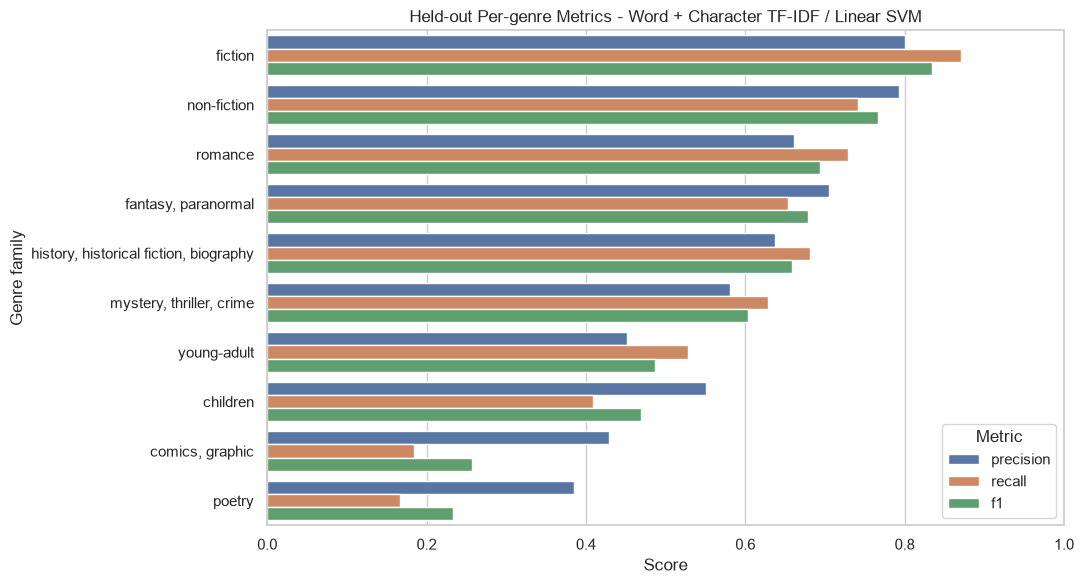

In [18]:
# Break aggregate test performance into precision, recall, F1, and support per genre.
per_genre_precision, per_genre_recall, per_genre_f1, per_genre_support = (
    precision_recall_fscore_support(
        y_test,
        final_test_predictions,
        average=None,
        zero_division=0,
    )
)
per_genre_average_precision = (
    average_precision_score(y_test, final_test_scores, average=None)
    if final_test_scores is not None
    else np.full(len(TARGET_GENRES), np.nan)
)

per_genre_metrics = pd.DataFrame(
    {
        "genre": TARGET_GENRES,
        "support": per_genre_support.astype(int),
        "precision": per_genre_precision,
        "recall": per_genre_recall,
        "f1": per_genre_f1,
        "average_precision": per_genre_average_precision,
    }
).sort_values("f1", ascending=False)

display(per_genre_metrics.round(3))

# Reshape to tidy form so all three metrics can share a grouped bar chart.
per_genre_long = per_genre_metrics.melt(
    id_vars=["genre", "support"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=per_genre_long,
    y="genre",
    x="score",
    hue="metric",
    orient="h",
)
plt.title(f"Held-out Per-genre Metrics - {selected_representation} / {selected_model}")
plt.xlabel("Score")
plt.ylabel("Genre family")
plt.xlim(0, 1)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_genre_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

In [19]:
# Convert binary target rows back to readable genre names for qualitative review.
def active_label_names(row: np.ndarray) -> list[str]:
    return [genre for genre, active in zip(TARGET_GENRES, row) if active]


# Compare truth and predictions book by book, then rank examples by total label mistakes.
test_error_analysis = analysis.loc[
    test_mask,
    ["book_id", "work_id", "title", "clean_description"],
].reset_index(drop=True)
test_error_analysis["true_genres"] = [
    " | ".join(active_label_names(row)) for row in y_test
]
test_error_analysis["predicted_genres"] = [
    " | ".join(active_label_names(row)) for row in final_test_predictions
]
test_error_analysis["missed_genres"] = [
    " | ".join(
        genre
        for genre, true_value, predicted_value in zip(TARGET_GENRES, true_row, predicted_row)
        if true_value and not predicted_value
    )
    for true_row, predicted_row in zip(y_test, final_test_predictions)
]
test_error_analysis["extra_genres"] = [
    " | ".join(
        genre
        for genre, true_value, predicted_value in zip(TARGET_GENRES, true_row, predicted_row)
        if predicted_value and not true_value
    )
    for true_row, predicted_row in zip(y_test, final_test_predictions)
]
test_error_analysis["label_error_count"] = np.abs(
    y_test - final_test_predictions
).sum(axis=1)

test_error_analysis = test_error_analysis.sort_values(
    ["label_error_count", "title"],
    ascending=[False, True],
)
display(
    test_error_analysis[
        ["book_id", "title", "true_genres", "predicted_genres", "label_error_count"]
    ].head(10)
)

,book_id,title,true_genres,predicted_genres,label_error_count
30,13086449,Gone,"fiction | non-fiction | fantasy, paranormal | mystery, thriller, crime",romance | young-adult | children,7
524,25964074,ناهمتا,"fiction | romance | fantasy, paranormal | mystery, thriller, crime | young-adult","history, historical fiction, biography | non-fiction",7
175,15991537,Diari,"fiction | history, historical fiction, biography | non-fiction | young-adult | children | comics...","fiction | fantasy, paranormal",6
242,28175648,Tatsuyuki Oyamato The 4th,"romance | comics, graphic","fiction | fantasy, paranormal | mystery, thriller, crime | young-adult",6
498,13797035,The Case of the Rock 'n' Roll Dog,"fiction | history, historical fiction, biography | mystery, thriller, crime | children | poetry","fiction | romance | fantasy, paranormal | mystery, thriller, crime | young-adult",6
120,15854025,Trains and Lovers,"fiction | romance | mystery, thriller, crime | young-adult","non-fiction | fantasy, paranormal",6
191,18750549,"Çöl Mızrağı (Demon Cycle, #2)","fiction | romance | fantasy, paranormal","fiction | history, historical fiction, biography | mystery, thriller, crime | young-adult | chil...",6
437,14288407,Das Glück trägt Cowboystiefel,"fiction | history, historical fiction, biography | romance | non-fiction","fiction | fantasy, paranormal | mystery, thriller, crime",5
196,26124639,Doctor Who: The Time Lord Letters,"fiction | romance | non-fiction | fantasy, paranormal | mystery, thriller, crime","history, historical fiction, biography | non-fiction",5
182,5997039,Hostage (Star Wars: Rebel Force #2),"fiction | history, historical fiction, biography | fantasy, paranormal | young-adult | children","fiction | romance | fantasy, paranormal | mystery, thriller, crime",5


### Result interpretation — genre-level performance and failure patterns

- The model is strongest for fiction (F1 0.834), non-fiction (0.767), romance (0.694), fantasy/paranormal (0.678), history/biography (0.659), and mystery/crime (0.604).
- Performance falls for young-adult (0.487), children (0.470), comics/graphic (0.257), and poetry (0.233). Support and F1 are strongly aligned (Spearman correlation 0.915 across the ten genres), so label scarcity is a central limitation.
- Poetry and comics/graphic have particularly low recall (0.167 and 0.184). Their average precision is higher than their thresholded F1 would suggest, which raises the testable question of whether per-label thresholds tuned only on validation data can recover more rare-label positives.
- Across the test set, 92 books have zero label errors, the median is two errors, and the mean is 1.755. Predictions average 2.73 labels per book versus 2.71 true weak labels, so the aggregate problem is not simply systematic over- or under-prediction.
- The highest-error examples often combine many weak labels and include multilingual titles or franchise/graphic works. This is evidence for targeted error slices by language, label cardinality, description length, and label provenance; it is not enough to attribute every error to the representation alone.

## 15. Two-dimensional semantic map

This qualitative view is fitted on development descriptions and transforms all eligible descriptions into a reusable 100-component LSA artifact. The map uses the first two components for the held-out test books; color uses the first active weak genre label only for visual orientation. The map is not itself an evaluation metric.

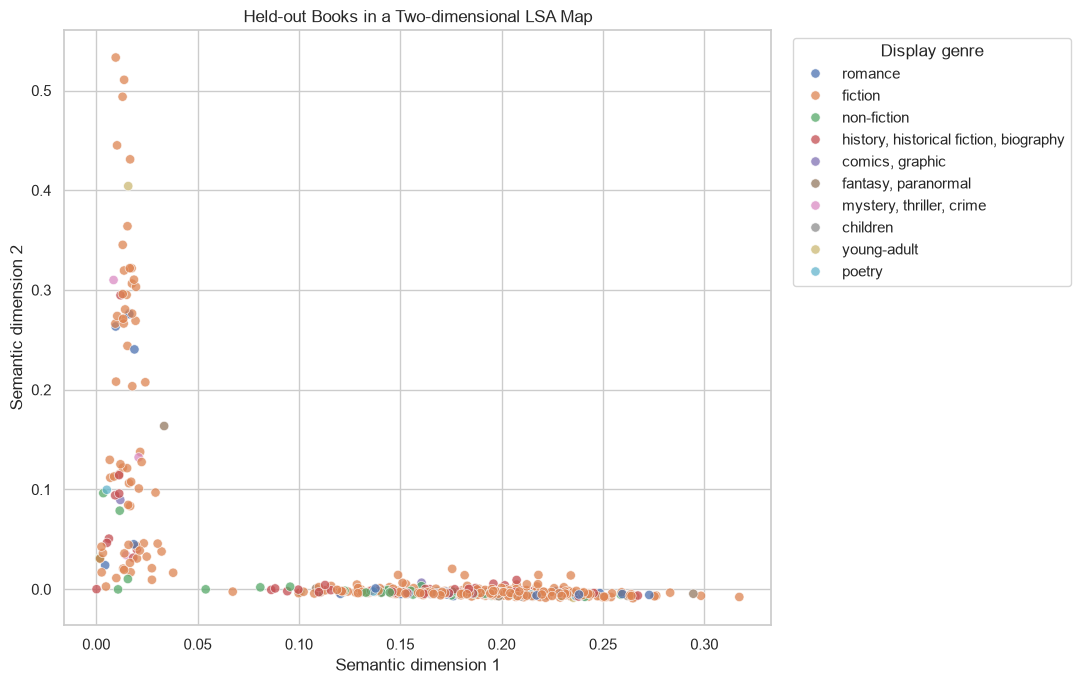

Plotly is not installed in this kernel; the optional interactive map was skipped.
First two LSA components explained variance: 1.43%
All 100 LSA components explained variance: 13.62%


In [20]:
# Fit the reusable semantic space on development text only, then transform every book.
semantic_vectorizer = word_vectorizer(max_features=30_000)
development_tfidf = semantic_vectorizer.fit_transform(
    X_development["clean_description"]
)
all_tfidf = semantic_vectorizer.transform(analysis["clean_description"])

semantic_svd = TruncatedSVD(
    n_components=100,
    n_iter=7,
    random_state=RANDOM_STATE,
)
semantic_svd.fit(development_tfidf)
all_lsa_coordinates = semantic_svd.transform(all_tfidf)

lsa_columns = [f"lsa_{component:03d}" for component in range(1, 101)]
book_lsa_features = pd.DataFrame(all_lsa_coordinates, columns=lsa_columns)
book_lsa_features.insert(0, "split", analysis["split"].to_numpy())
book_lsa_features.insert(0, "work_id", analysis["work_id"].to_numpy())
book_lsa_features.insert(0, "book_id", analysis["book_id"].to_numpy())

# Use two dimensions for visualization only; retain all 100 components for export.
test_coordinates = all_lsa_coordinates[test_mask, :2]

semantic_map = analysis.loc[test_mask, ["book_id", "title"]].reset_index(drop=True)
semantic_map["semantic_dimension_1"] = test_coordinates[:, 0]
semantic_map["semantic_dimension_2"] = test_coordinates[:, 1]
semantic_map["display_genre"] = [
    active_label_names(row)[0] if active_label_names(row) else "No included label"
    for row in y_test
]
semantic_map["true_genres"] = [
    " | ".join(active_label_names(row)) for row in y_test
]

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=semantic_map,
    x="semantic_dimension_1",
    y="semantic_dimension_2",
    hue="display_genre",
    s=45,
    alpha=0.75,
)
plt.title("Held-out Books in a Two-dimensional LSA Map")
plt.xlabel("Semantic dimension 1")
plt.ylabel("Semantic dimension 2")
plt.legend(title="Display genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "semantic_map_test.png", dpi=160, bbox_inches="tight")
plt.show()

# Export an interactive view when Plotly is available without making it a hard dependency.
if px is not None:
    interactive_map = px.scatter(
        semantic_map,
        x="semantic_dimension_1",
        y="semantic_dimension_2",
        color="display_genre",
        hover_name="title",
        hover_data={"book_id": True, "true_genres": True},
        title="Interactive Held-out LSA Semantic Map",
        labels={
            "semantic_dimension_1": "Semantic dimension 1",
            "semantic_dimension_2": "Semantic dimension 2",
            "display_genre": "Display genre",
        },
    )
    interactive_map.update_traces(marker={"size": 8, "opacity": 0.75})
    interactive_map.write_html(
        FIGURES_DIR / "semantic_map_test_interactive.html",
        include_plotlyjs="cdn",
    )
    interactive_map.show()
else:
    print("Plotly is not installed in this kernel; the optional interactive map was skipped.")

print(
    "First two LSA components explained variance: "
    f"{semantic_svd.explained_variance_ratio_[:2].sum():.2%}"
)
print(
    "All 100 LSA components explained variance: "
    f"{semantic_svd.explained_variance_ratio_.sum():.2%}"
)

### Result interpretation — LSA map and compression

- The first two LSA components explain only 1.43% of TF-IDF variance, so this plot is an intentionally lossy view of the 100-dimensional representation. The visible genre overlap does not contradict the approximately 0.559 validation Macro F1 achieved when classifiers use all 100 components.
- All 100 components explain 13.62% of TF-IDF variance while reducing up to 30,000 word features to 100 dense coordinates. The compression preserves useful classification signal but leaves substantial document-specific variation outside the representation.
- Colors show only the first active weak genre for each multi-label book, and LSA is fitted without genre supervision. Clear color-separated clusters should therefore not be expected. Component terms and extreme books must be inspected before assigning human meanings to either axis.
- Plotly's absence skipped only the optional interactive rendering; it did not affect LSA fitting, the static map, exported coordinates, or evaluation.

## 16. Export reproducible research artifacts

In [21]:
# Export stable feature, metric, and diagnostic artifacts for reuse by later notebooks.
text_feature_export_columns = [
    "book_id",
    "work_id",
    "title",
    "split",
    *lexical_feature_columns,
]
book_text_features = analysis[text_feature_export_columns].copy()
book_text_features["weak_genres"] = analysis["genres"].map(" | ".join)

# Document each generated feature family and its missingness alongside the datasets.
feature_inventory = pd.DataFrame(
    [
        {
            "feature": feature,
            "family": "Lexical",
            "dtype": str(analysis[feature].dtype),
            "missing_count": int(analysis[feature].isna().sum()),
            "missing_rate": float(analysis[feature].isna().mean()),
            "unique_values": int(analysis[feature].nunique(dropna=False)),
        }
        for feature in lexical_feature_columns
    ]
    + [
        {
            "feature": "word_tfidf",
            "family": "Sparse semantic representation",
            "dtype": "float32 sparse matrix",
            "missing_count": 0,
            "missing_rate": 0.0,
            "unique_values": np.nan,
        },
        {
            "feature": "character_tfidf",
            "family": "Sparse semantic representation",
            "dtype": "float32 sparse matrix",
            "missing_count": 0,
            "missing_rate": 0.0,
            "unique_values": np.nan,
        },
        {
            "feature": "lsa_100",
            "family": "Dense semantic representation",
            "dtype": f"{book_lsa_features[lsa_columns[0]].dtype} dense matrix",
            "missing_count": 0,
            "missing_rate": 0.0,
            "unique_values": np.nan,
        },
    ]
)

# Persist compact tables and reusable matrices; plotting cells save their own figures.
book_text_features.to_parquet(
    PROCESSED_DIR / "book_text_features_v1.parquet",
    index=False,
)
book_lsa_features.to_parquet(
    PROCESSED_DIR / "book_lsa_features_v1.parquet",
    index=False,
)
corpus_summary.to_csv(REPORTS_DIR / "notebook04_corpus_profile.csv", index=False)
vocabulary_diagnostics.to_csv(
    REPORTS_DIR / "notebook04_vocabulary_diagnostics.csv",
    index=False,
)
model_comparison.to_csv(REPORTS_DIR / "notebook04_model_comparison.csv", index=False)
final_test_metrics.to_csv(REPORTS_DIR / "notebook04_final_test_metrics.csv", index=False)
per_genre_metrics.to_csv(REPORTS_DIR / "notebook04_per_genre_metrics.csv", index=False)
test_error_analysis.to_csv(REPORTS_DIR / "notebook04_error_analysis.csv", index=False)
feature_inventory.to_csv(REPORTS_DIR / "notebook04_feature_inventory.csv", index=False)

exported_artifacts = pd.DataFrame(
    {
        "artifact": [
            "research_split_v1.parquet",
            "book_text_features_v1.parquet",
            "book_lsa_features_v1.parquet",
            "notebook04_corpus_profile.csv",
            "notebook04_vocabulary_diagnostics.csv",
            "notebook04_model_comparison.csv",
            "notebook04_final_test_metrics.csv",
            "notebook04_per_genre_metrics.csv",
            "notebook04_error_analysis.csv",
            "notebook04_feature_inventory.csv",
        ],
        "location": [
            str(PROCESSED_DIR / "research_split_v1.parquet"),
            str(PROCESSED_DIR / "book_text_features_v1.parquet"),
            str(PROCESSED_DIR / "book_lsa_features_v1.parquet"),
            str(REPORTS_DIR / "notebook04_corpus_profile.csv"),
            str(REPORTS_DIR / "notebook04_vocabulary_diagnostics.csv"),
            str(REPORTS_DIR / "notebook04_model_comparison.csv"),
            str(REPORTS_DIR / "notebook04_final_test_metrics.csv"),
            str(REPORTS_DIR / "notebook04_per_genre_metrics.csv"),
            str(REPORTS_DIR / "notebook04_error_analysis.csv"),
            str(REPORTS_DIR / "notebook04_feature_inventory.csv"),
        ],
    }
)
display(exported_artifacts)

,artifact,location
0,research_split_v1.parquet,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/research_split_...
1,book_text_features_v1.parquet,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/book_text_featu...
2,book_lsa_features_v1.parquet,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/book_lsa_featur...
3,notebook04_corpus_profile.csv,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_corpus_prof...
4,notebook04_vocabulary_diagnostics.csv,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_vocabulary_...
5,notebook04_model_comparison.csv,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_model_compa...
6,notebook04_final_test_metrics.csv,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_final_test_...
7,notebook04_per_genre_metrics.csv,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_per_genre_m...
8,notebook04_error_analysis.csv,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_error_analy...
9,notebook04_feature_inventory.csv,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_feature_inv...


## 17. Measured conclusion and limitations

In [22]:
# Compare the best validation result from each representation family with metadata alone.
best_metadata_validation = model_comparison.loc[
    model_comparison["representation"] == "Metadata",
    "validation_macro_f1",
].max()
best_semantic_validation = model_comparison.loc[
    model_comparison["representation"].isin(
        ["Lexical", "Word TF-IDF", "Word + Character TF-IDF", "LSA"]
    ),
    "validation_macro_f1",
].max()
best_combined_validation = model_comparison.loc[
    model_comparison["representation"] == "Combined",
    "validation_macro_f1",
].max()

conclusion_summary = pd.DataFrame(
    {
        "comparison": [
            "Best metadata validation Macro F1",
            "Best semantic-only validation Macro F1",
            "Best combined validation Macro F1",
            "Selected final test Macro F1",
        ],
        "value": [
            best_metadata_validation,
            best_semantic_validation,
            best_combined_validation,
            final_test_metric_values["macro_f1"],
        ],
    }
)
display(conclusion_summary.round(4))

# Express improvements as Macro F1 deltas before restating the weak-label boundary.
semantic_delta = best_semantic_validation - best_metadata_validation
combined_delta = best_combined_validation - best_metadata_validation

print(
    "Semantic-only validation change versus metadata: "
    f"{semantic_delta:+.4f} Macro F1."
)
print(
    "Combined validation change versus metadata: "
    f"{combined_delta:+.4f} Macro F1."
)
print(
    "Interpretation boundary: these results measure agreement with weak Goodreads genre signals "
    "on the eligible 5,000-book prototype sample. They do not establish authoritative literary "
    "classification quality or production search performance."
)

,comparison,value
0,Best metadata validation Macro F1,0.4707
1,Best semantic-only validation Macro F1,0.5626
2,Best combined validation Macro F1,0.5611
3,Selected final test Macro F1,0.5681


Semantic-only validation change versus metadata: +0.0919 Macro F1.
Combined validation change versus metadata: +0.0904 Macro F1.
Interpretation boundary: these results measure agreement with weak Goodreads genre signals on the eligible 5,000-book prototype sample. They do not establish authoritative literary classification quality or production search performance.


## Research checkpoint

**Status:** Notebook 04 is complete. All 19 code cells were executed sequentially without error, the saved outputs were reviewed, and the reusable split, feature, metric, diagnostic, and error-analysis artifacts were exported. Plotly was unavailable only for the optional interactive map.

### Answers established by this notebook

1. **Best classical baseline:** Word + Character TF-IDF with a class-balanced Linear SVM (`C=0.05`) leads validation Macro F1 at 0.5626 and achieves 0.5681 on the final held-out test set.
2. **Semantic value:** The best semantic-only validation result exceeds metadata by 0.0919 Macro F1, providing clear evidence that descriptions add subject-matter information beyond structured fields.
3. **Combined value:** The best Combined result is 0.5611 validation Macro F1, 0.0015 below the selected semantic-only model. The current metadata and lexical features do not add measurable balanced-label performance beyond word-plus-character text.
4. **Primary limitation:** Performance is strongly related to label support. Fiction and non-fiction are strong, while poetry, comics/graphic, children, and young-adult remain difficult because of scarce positives, overlapping categories, weak-label ambiguity, and possible multilingual effects.
5. **Stability:** Validation and test results are close, and the final test result lies near the grouped cross-validation range. The classical baseline is stable enough to serve as the comparison point for Notebook 05.

### Decisions carried forward

- Freeze `research_split_v1.parquet` and the 0.5681 test Macro F1 result as the classical benchmark. Do not use the current test partition for further model or threshold selection.
- Begin Notebook 05 on the same 3,497-book eligible cohort and frozen work-group split so changes can be attributed to representation rather than data selection. Scale to a larger sample only after the transformer comparison works end to end on this controlled cohort.
- Keep Macro F1 as the primary metric. Continue reporting Micro F1, macro average precision, per-genre metrics, subset accuracy, and Hamming loss to expose imbalance and multi-label tradeoffs.
- Treat Goodreads genres as weak, overlapping supervision rather than authoritative literary categories.

### Open questions for Notebook 05 and follow-on research

1. Do pretrained sentence embeddings improve Macro F1 beyond 0.5681 when evaluated on the identical split, especially for low-support genres?
2. Does a multilingual embedding model outperform an English-focused model for non-English and mixed-language descriptions?
3. Can per-label decision thresholds, selected strictly within training cross-validation or validation data, improve poetry and comics/graphic recall without unacceptable precision loss?
4. How does performance vary by language, description length, label cardinality, and genre support?
5. Do transformer embeddings improve semantic-neighbor quality and retrieval behavior even when classification gains are small?
6. After the controlled 5,000-book comparison, what learning curve and compute tradeoffs justify scaling to 25,000 books?
7. Should weak-label construction be refined through hierarchy, confidence weighting, or shelf-quality filtering before later topic, clustering, and search experiments?